# Генеративные классификаторы
Рассмотрим генеративный подход к классификации.
## Дискриминативные и генеративные алгоритмы
Некоторые алгоритмы, например, логистическая регрессия, стремятся найти
разделяющую классы границу (гиперплоскость). Такие алгоритмы называются
**дискриминативными** (от англ. discriminate — «различать», «разграничивать»).

Более формально, речь идет о модели $h$ с параметрами $\theta \in \Theta,$
отображающей признаки $x \in X$ на целевую переменную $y \in Y.$

$$h_{\theta}: X \rightarrow Y $$

В случае логистической регрессии, $ h_{\theta} : X \rightarrow [0, 1]. $
Вероятностная интерпретация дискриминативной модели заключается в
использовании метода максимального условного правдоподобия (conditional
maximum likelihood estimation)

$$ \max_{\theta} \frac{1}{N}\prod_{i=1}^N P_\theta(y_i \mid x_i) = \max_{\theta}
\frac{1}{N}\sum_{i=1}^N \log P_\theta(y_i \mid x_i) $$

Другими словами, мы должны выбрать такие значения $\theta,$ чтобы для каждого
из $N$ наблюдений $x_i$ вероятность правильного значения $y_i$ была наиболее
высокой.

В случае логистической регрессии функция потерь (бинарная кросс-энтропия)
будет иметь вид

$$ \begin{split} \begin{align} \ell(\theta) & = \frac{1}{N}\sum_{i=1}^N \log P_\theta
(y_i \mid x_i) \\ & = \frac{1}{N}\sum_{i=1}^N {y_i} \cdot \log \sigma(\theta^\top x_i) +
(1-y_i) \cdot \log (1-\sigma(\theta^\top x_i)). \end{align} \end{split} $$

Другой тип **генеративных** (generative) алгоритмов строит вероятностную модель
данных $x$ для каждого класса $c \in C$

$$ P_\theta(x \mid y=c), $$

а также учитывает долю класса в объеме общего набора данных $P_\theta(y=c), $
максимизируя, таким образом, совместную вероятность данных и меток.

$$ \max_\theta \frac{1}{N}\sum_{i=1}^N \log P_\theta(x_i, y_i) $$

Формула Байеса позволяет объединить вероятностную модель (в контексте
формулы речь идет о правдоподобии признака для класса $c$) и долю класса в
общей выборке (априорное знание) для создания апостериорной вероятности
принадлежности нового наблюдения $x’$ к одному из классов.

$$ \begin{split} \begin{align} \underset{c}{\operatorname{argmax}} P_\theta(y=c \mid
x’) & = \underset{c}{\operatorname{argmax}} \frac{P_\theta(x’ \mid y=c)
P_\theta(y=c)}{P_\theta(x’)} \\ & \propto \underset{c}{\operatorname{argmax}}
P_\theta(x’ \mid y=c) P_\theta(y=c) \end{align} \end{split} $$

Рассмотрим сказанное выше на примере.

## Классификатор спама

Поставим задачу создать классификатор спама, используя теорему Байеса.
Рассмотрим электронные письма, в которых обычные сообщения (ham) отнесены к
классу $y=0,$ а спам (spam) — к $y=1.$

Для простоты предположим, что у нас 15 сообщений (10 обычных и 5 спам
сообщений), которые состоят из $d = 4$ слов: $x_1$ «добрый», $x_2$ «день», $x_3$
«спасибо», $x_4$ «деньги».

Пусть задана следующая частота (правдоподобие), с которой каждое из слов
встречается в обычных (17 слов)

$$\begin{array}{ll} P(x_1 \mid y=0) = \frac{8}{17} \\ P(x_2 \mid y=0) = \frac{5}{17} \\
P(x_3 \mid y=0) = \frac{3}{17} \\ P(x_4 \mid y=0) = \frac{1}{17} \end{array} $$

и спам (7 слов) сообщениях

$$\begin{array}{ll} P(x_1 \mid y=1) = \frac{2}{7} \\ P(x_2 \mid y=1) = \frac{1}{7} \\
P(x_3 \mid y=1) = \frac{0}{7} \\ P(x_4 \mid y=1) = \frac{4}{7} \end{array} $$

Априорной вероятностью будет частота класса в общем наборе данных, то есть
$P(y=0) = \frac{10}{15} = \frac{2}{3}$ и $P(y=1) = \frac{5}{15} = \frac{1}{3}.$

Априорную вероятность классов и правдоподобие каждого из слов можно
представить и так.

![](https://drive.google.com/uc?export=view&id=1TVzflEvvubdH-doZTTyKkzvZyeQhmaa5)

Найдем апостериорную вероятность принадлежности слова «день» к обычным

$$ \begin{array}{ll} P(y=0 \mid x_2) &= \frac{P(x_2 \mid y=0) P(y=0)}{P(x_2)} \\ &=
\frac{P(x_2 \mid y=0) P(y=0)}{P(x_2 \mid y=0)P(y=0) + P(x_2 \mid y=1)P(y=1)} \\ &=
\frac{ \frac{5}{17} \cdot \frac{10}{15} }{ \frac{5}{17} \cdot \frac{10}{15} + \frac{1}
{7} \cdot \frac{5}{15} } \approx 0{,}8 \end{array} $$

и спам сообщениям

$$ \begin{array}{ll} P(y=1 \mid x_2) &= \frac{P(x_2 \mid y=1) P(y=1)}{P(x_2)} \\ &=
\frac{P(x_2 \mid y=1) P(y=1)}{P(x_2 \mid y=0)P(y=0) + P(x_2 \mid y=1)P(y=1)} \\ &=
\frac{ \frac{1}{7} \cdot \frac{5}{15} }{ \frac{5}{17} \cdot \frac{10}{15} + \frac{1}{7}
\cdot \frac{5}{15} } \approx 0{,}2 \end{array} $$

Поскольку знаменатель в обоих случаях одинаковый, достаточно рассчитать
числитель.

$$ P(y=0 \mid x_2) \propto P(x_2 \mid y=0) P(y=0) = \frac{5}{17} \cdot \frac{10}{15}
\approx 0{,}2 $$

$$ P(y=1 \mid x_2) \propto P(x_2 \mid y=1) P(y=1) = \frac{1}{7} \cdot \frac{5}{15}
\approx 0{,}05 $$

Предположим, что нам нужно классифицировать новое сообщение, состоящее из
двух слов «добрый день». Другими словами, нам нужно найти

$$ P(y \mid x_1, x_2) = \frac{P(x_1, x_2 \mid y) P(y)}{P(x_1, x_2)}, $$

что предполагает нахождение совместной вероятности нескольких зависимых
событий (слов) $x_j.$

$$ \begin{array}{ll} P(y \mid x_1, x_2) &= \frac{P(x_1 \mid y, x_2) P(x_2 \mid y) P(y)}
{P(x_1, x_2)} \\ &\propto P(x_1 \mid y, x_2) P(x_2 \mid y) P(y) \end{array} $$

Ведь, в самом деле, логично предположить, что появление в сообщении слова
«добрый» влияет на появление в этом же сообщении слова «день».

При этом байесовский классификатор «наивно» допускает, что эти события
(появление слов) не зависят друг от друга (independence assumption). В этом случае
расчет совместной вероятности упрощается.

$$ \begin{array}{ll} P(y \mid x_1, x_2) &= \frac{P(x_1 \mid y) P(x_2 \mid y) P(y)}
{P(x_1, x_2)} \\ &\propto P(x_1 \mid y) P(x_2 \mid y) P(y) \end{array} $$

В нашем примере,

$$ P(x_1 \mid y=0) P(x_2 \mid y=0) P(y=0) = \frac{8}{17} \cdot \frac{5}{17} \cdot
\frac{10}{15} \approx 0{,}09$$

$$ P(x_1 \mid y=1) P(x_2 \mid y=1) P(y=1) = \frac{2}{7} \cdot \frac{1}{7} \cdot
\frac{5}{15} \approx 0{,}01$$

В общем случае для $d$ признаков, совместная вероятность событий

$$ P(y \mid x_1, \dots, x_d) = \frac{P(y) P(x_1, \dots, x_d \mid y)} {P(x_1, \dots, x_d)}
$$

на основе допущения об их независимости

$$ P(x_j \mid y, x_1, \dots, x_{j-1}, x_{j+1}, \dots, x_d) = P(x_j \mid y) $$

принимает вид

$$ P(y \mid x_1, \dots, x_d) = \frac{P(y) \prod_{j=1}^{d} P(x_i \mid y)} {P(x_1, \dots,
x_d)} \propto P(y) \prod_{j=1}^{d} P(x_j \mid y) $$

Таким образом, задача предсказания класса сводится к

$$ \begin{array}{ll} \hat{y} &= \underset{c}{\operatorname{argmax}} P(y=c)
\prod_{j=1}^{d} P(x_j \mid y=c) \\ &= \underset{c}{\operatorname{argmax}} \log
P(y=c) + \sum_{j=1}^{d} \log P(x_j \mid y=c) \end{array} $$

## Сглаживание по Лапласу
Предположим, что нам нужно классифицировать новое сообщение, состоящее из
слов «спасибо деньги деньги». Найдем вероятность того, что это спам.

$$ P(y=1 \mid x_3, x_4, x_4) \propto \frac{0}{7} \cdot \left( \frac{4}{7} \right)^2 \cdot
\frac{5}{15} = 0 $$

Получается, что любое сообщение, содержащее слово «спасибо», автоматически
классифицируется как обычное, хотя очевидно, что некоторые сообщения могут
быть спамом.

Для решения этой проблемы используется аддитивное сглаживание, при котором
частота каждого слова $\hat{\theta}_j$ увеличивается на $\alpha.$ Если $\alpha=1,$
речь идет о сглаживании по Лапласу (Laplace smoothing или add-one smoothing).

$$ \hat{\theta}_j = \frac{x_j+\alpha}{N+\alpha d}, $$

где $N$ — общее количество слов в данном классе, а $d$ — количество
уникальных слов. В примере выше, при использовании сглаживания по Лапласу
правдоподобие слова «спасибо» в классе «спам» будет равно

$$ \hat{\theta}_3 = \frac{x_3+\alpha}{N+\alpha d} = \frac{0+1}{7 + 1 \cdot 4} =
\frac{1}{11} $$

Найдем сглаженные вероятности сообщения «спасибо деньги деньги».

$$ P(y=0 \mid x_3, x_4, x_4) \propto \frac{4}{21} \cdot \left( \frac{2}{21} \right)^2
\cdot \frac{10}{15} \approx 0{,}001 $$

$$ P(y=1 \mid x_3, x_4, x_4) \propto \frac{1}{11} \cdot \left( \frac{5}{11} \right)^2
\cdot \frac{5}{15} \approx 0{,}006 $$

## Multinomial Naïve Bayes
Рассмотренный выше наивный байесовский классификатор называется
**мультиномиальным** (Multinomial Naïve Bayes), потому что признаки (слова)
следуют мультиномиальному распределению

$$ X \sim M_d (N; p_1, \ldots, p_d), $$

где $N$ — общее количество слов в одном классе, а $d$ — количество уникальных
слов.

В частности, распределение слов в классе спам сообщений (с учетом сглаживания)
имеет параметры

$$ X \sim M_4 \left( 11; \frac{3}{11}, \frac{2}{11}, \frac{1}{11}, \frac{5}{11} \right)
$$

Реализуем классификатор в коде. Возьмем набор данных SMS Spam Collection.

Создадим класс MultinomialNaiveBayes.

In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import re
from sklearn.datasets import load_iris

## Multinomial Naïve Bayes

In [2]:
spam_df = pd.read_csv('/content/spam.csv', encoding='latin-1')

spam_df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace = True)
spam_df.rename(columns={'v1':'is_spam', 'v2':'text'}, inplace = True)
spam_df.is_spam = spam_df.is_spam.apply(lambda x: True if x == 'spam' else False)
spam_df.drop_duplicates(keep='first', inplace=True)
spam_df.reset_index(drop=True, inplace=True)

spam_df.head()

,is_spam,text
0,False,"Go until jurong point, crazy.. Available only ..."
1,False,Ok lar... Joking wif u oni...
2,True,Free entry in 2 a wkly comp to win FA Cup fina...
3,False,U dun say so early hor... U c already then say...
4,False,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
class MultinomialNaiveBayes:
  def __init__(self, alpha = 1):
    self.alpha = alpha
    self.token_spam_counts = defaultdict(int)
    self.token_ham_counts = defaultdict(int)
    self.spam_messages = self.ham_messages = 0

  def tokenize(self, text):
    text = text.lower()
    all_words = re.findall("[a-z']+", text)
    return all_words

  def fit(self, data):
    for message in data.itertuples():
      if message.is_spam:
        self.spam_messages += 1
      else:
        self.ham_messages += 1

      for token in self.tokenize(message.text):
        if message.is_spam:
          self.token_spam_counts[token] += 1
        else:
          self.token_ham_counts[token] += 1

  def _likelihood(self, token):
    spam = self.token_spam_counts[token]
    ham = self.token_ham_counts[token]

    total_spam_words = sum(self.token_spam_counts.values())
    total_ham_words = sum(self.token_ham_counts.values())

    unique_spam_words = len(self.token_spam_counts)
    unique_ham_words = len(self.token_ham_counts)

    p_token_spam = (spam + self.alpha) / (total_spam_words + self.alpha * unique_spam_words)
    p_token_ham = (ham + self.alpha) / (total_ham_words + self.alpha * unique_ham_words)

    return p_token_spam, p_token_ham

  def predict(self, data):
    log_spam_prior = np.log(self.spam_messages / len(data))
    log_ham_prior = np.log(self.ham_messages / len(data))

    data['predictions'] = False

    for message in data.itertuples():
      text_tokens = self.tokenize(message.text)
      log_prob_if_spam = log_prob_if_ham = 0.0

      for token in text_tokens:
        prob_if_spam, prob_if_ham = self._likelihood(token)
        log_prob_if_spam += np.log(prob_if_spam)
        log_prob_if_ham += np.log(prob_if_ham)

      log_prob_if_spam = log_spam_prior + log_prob_if_spam
      log_prob_if_ham = log_ham_prior + log_prob_if_ham

      data.loc[message.Index, 'predictions'] = log_prob_if_spam > log_prob_if_ham

    return data

Обучим модель, сделаем прогноз и оценим качество.

In [4]:
model = MultinomialNaiveBayes()
model.fit(spam_df)
spam_df = model.predict(spam_df)

accuracy_score(spam_df.is_spam, spam_df.predictions)

0.9883923389437028

## Генеративная модель
Хотя в данном случае это не имеет большого практического смысла,
продемонстрируем, как генеративная модель, запомнив параметры распределений
обычных и спам сообщений, способна создавать новые тексты.

Дважды используем функцию **np.random.multinomial()** для обычных и спам
сообщений. В каждом случае передадим количество слов в сообщении (пусть их
будет три), правдоподобие (с учетом сглаживания) и количество сообщений
(соответствующее априорной вероятности).

In [5]:
np.random.multinomial(3, [9/21, 6/21, 4/21, 2/21], size = 10)

array([[2, 1, 0, 0],
       [2, 1, 0, 0],
       [1, 1, 1, 0],
       [2, 0, 0, 1],
       [1, 0, 2, 0],
       [2, 1, 0, 0],
       [2, 1, 0, 0],
       [2, 0, 1, 0],
       [2, 1, 0, 0],
       [0, 1, 0, 2]])

In [6]:
np.random.multinomial(3, [3/11, 2/11, 1/11, 5/11], size = 5)

array([[2, 1, 0, 0],
       [1, 0, 0, 2],
       [1, 0, 1, 1],
       [2, 0, 1, 0],
       [0, 2, 0, 1]])

Первое спам сообщение [1, 1, 0, 1] состоит из слов $x_1, x_2, x_4,$ то есть «добрый
день деньги».

## Gaussian Naïve Bayes
В случае если данные содержат количественные признаки, можно использовать
**гауссовский наивный байесовский классификатор** (Gaussian Naïve Bayes).
Основными допущениями такой модели являются:
* независимость признаков $x_j;$ а также их
* нормальное распределение

$$ P(x_{cj} \mid y = c, \mu_{cj}, \sigma_{cj}^2) = \frac{1}{\sqrt{ 2 \pi \sigma_{cj}^2
}} \exp \left[ -\frac{(x_{cj}-\mu_{cj})^2}{2\sigma_{cj}^2} \right] $$

Этапы моделирования, таким образом, заключаются в том, чтобы:
1. оценить априорную вероятность класса $P(y = c);$
2. для каждого признака $j$ внутри каждого класса $c$ найти выборочные
параметры $\hat{\mu}_{cj}$ и $\hat{\sigma}_{cj},$ задав $P(x_{cj} \mid y = c,
\mu_{cj}, \sigma_{cj}^2),$
3. для нового наблюдения:
  * для каждого признака и внутри каждого предсказываемого класса,
  используя параметры $\hat{\mu}_{cj}$ и $\hat{\sigma}_{cj},$ найти
значения плотности вероятности;
  * найти апостериорную вероятность для каждого класса $c$ и выбрать тот
класс, апостериорная оценка которого наиболее высока

$$ P(y = c \mid x_1, \dots, x_d) \propto P(y = c) \prod_{j=1}^{d} P(x_j \mid y = c) $$

$$ \begin{array}{ll} \hat{y} &= \underset{c}{\operatorname{argmax}} P(y=c)
\prod_{j=1}^{d} P(x_j \mid y=c) \\ &= \underset{c}{\operatorname{argmax}} \log
P(y=c) + \sum_{j=1}^{d} \log P(x_j \mid y=c). \end{array} $$

**MLE-оценка.** Докажем, что параметры $\hat{\mu}_{cj}$ и $\hat{\sigma}_{cj}$
максимизируют правдоподобие данных внутри каждого класса. Будем
рассматривать данные $x = \left\lbrace x_1, \ldots, x_N \right\rbrace,$ состоящие из
одного признака в рамках одного класса

$$ x_i \sim \mathcal{N}(\mu, \sigma^2), \quad i = 1, \ldots, N \; . $$

Таким образом, необходимо продемонстрировать, что

$$ \begin{split} \hat{\mu} &= \frac{1}{N} \sum_{i=1}^N x_i \\ \hat{\sigma}^2 &=
\frac{1}{N} \sum_{i=1}^N (x_i-\bar{x})^2 \; , \end{split} $$

где $\bar{x} = \frac{1}{N} \sum_{i=1}^N x_i.$ Правдоподобие одного наблюдения
можно задать через

$$ p(x_i \mid \mu,\sigma^2) = \mathcal{N}(x; \mu, \sigma^2) = \frac{1}{\sqrt{2 \pi
\sigma^2}} \cdot \exp \left[ -\frac{1}{2} \left( \frac{x_i-\mu}{\sigma} \right)^2 \right] $$

Предполагая независимость наблюдений,

$$ p(x \mid \mu,\sigma^2) = \prod_{i=1}^N p(x_i \mid \mu) = \sqrt{ \frac{1}{(2 \pi
\sigma^2)^N} } \cdot \exp \left[ -\frac{1}{2} \sum_{i=1}^{N} \left( \frac{x_i-\mu}
{\sigma} \right)^2 \right] $$

Преобразуем выражение,

\begin{split} p(x \mid \mu,\sigma^2) &= \left( \frac{1}{2 \pi \sigma^2} \right)^{N/2}
\cdot \exp \left[ -\frac{1}{2} \sum_{i=1}^{N} \left( \frac{x_i^2 — 2 x_i \mu + \mu^2}
{\sigma^2} \right) \right] \\ &= \left( \frac{1}{2 \pi \sigma^2} \right)^{N/2} \cdot \exp
\left[ -\frac{1}{2 \sigma^2} \left( x^\mathrm{T} x-2 N \bar{x} \mu + N \mu^2 \right)
\right], \end{split}

где $\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i$ и $x^\mathrm{T} x =
\sum_{i=1}^{N} x_i^2.$

Логарифмическая функция правдоподобия будет иметь вид

$$ \begin{split} \ell (\mu,\sigma^2) &= \log p(x \mid \mu,\sigma^2) \\ &= -\frac{N}{2}
\log (2 \pi \sigma^2)-\frac{1}{2 \sigma^2} \left( x^\mathrm{T} x-2 N \bar{x} \mu + N
\mu^2 \right) \end{split} $$

Найдем производную относительно $\mu$

$$ \frac{\mathrm{d}\ell(\mu,\sigma^2)}{\mathrm{d}\mu} = \frac{N \bar{y}}{\sigma^2}
— \frac{N \mu}{\sigma^2} = \frac{N}{\sigma^2} (\bar{y}-\mu) $$
и приравняем ее к нулю

$$ \begin{split} \frac{\mathrm{d}\ell(\hat{\mu},\sigma^2)}{\mathrm{d}\mu} &= 0 \\ 0
&= \frac{N}{\sigma^2} (\bar{x}-\hat{\mu}) \ 0 &= \bar{x}-\hat{\mu} \\ \hat{\mu} &=
\bar{x} \\ \hat{\mu} &= \frac{1}{N} \sum_{i=1}^N x_i \end{split} $$

Найдем производную функции правдоподобия со значением $\hat{\mu}$
относительно $\sigma^2$

$$ \begin{split} \frac{\mathrm{d}\ell(\hat{\mu},\sigma^2)}{\mathrm{d}\sigma^2} &= -
\frac{N}{2} \frac{1}{\sigma^2} + \frac{1}{2 (\sigma^2)^2} \left( x^\mathrm{T} x-2 N
\bar{x} \hat{\mu} + N \hat{\mu}^2 \right) \\ &= -\frac{N}{2 \sigma^2} + \frac{1}{2
(\sigma^2)^2} \sum_{i=1}^N \left( x_i^2-2 x_i \hat{\mu} + \hat{\mu}^2 \right) \\ &= -
\frac{N}{2 \sigma^2} + \frac{1}{2 (\sigma^2)^2} \sum_{i=1}^N (x_i-\hat{\mu})^2
\end{split} $$

и приравняем ее к нулю

$$ \begin{split} \frac{\mathrm{d}\ell(\hat{\mu},\hat{\sigma}^2)}{\mathrm{d}\sigma^2}
&= 0 \\ 0 &= \frac{1}{2 (\hat{\sigma}^2)^2} \sum_{i=1}^N (x_i-\hat{\mu})^2 \\
\frac{N}{2 \hat{\sigma}^2} &= \frac{1}{2 (\hat{\sigma}^2)^2} \sum_{i=1}^N (x_i-
\hat{\mu})^2 \\ \frac{2 (\hat{\sigma}^2)^2}{N} \cdot \frac{N}{2 \hat{\sigma}^2} &=
\frac{2 (\hat{\sigma}^2)^2}{N} \cdot \frac{1}{2 (\hat{\sigma}^2)^2} \sum_{i=1}^N
(x_i-\hat{\mu})^2 \\ \hat{\sigma}^2 &= \frac{1}{N} \sum_{i=1}^N (x_i-\hat{\mu})^2 \\
\hat{\sigma}^2 &= \frac{1}{N} \sum_{i=1}^N (x_i-\bar{x})^2 \\ \end{split} $$

**Приведем пример.** Предположим, что параметры первого признака:
* для класса $y=0$ равны $\hat{\mu}_{01}= 24$ и $\hat{\sigma}_{01}=4;$ а для
* $y=1$ соответственно $\hat{\mu}_{11}= 15$ и $\hat{\sigma}_{11}=2;$
Для второго признака:
* для класса $y=0$ равны $\hat{\mu}_{02}= 480$ и $\hat{\sigma}_{02}=25;$
$y=1:$ $\hat{\mu}_{12}= 505$ и $\hat{\sigma}_{12}=30;$

Наконец для третьего признака:

* для класса $y=0$ равны $\hat{\mu}_{03}= 35$ и $\hat{\sigma}_{03}=4;$
* $y=1:$ $\hat{\mu}_{13}= 25$ и $\hat{\sigma}_{13}=4;$

Кроме того, поскольку 10 из двадцати наблюдений относятся к одному классу, а
ещё 10 — ко второму, то априорная вероятность принадлежности к каждому из
классов равна:

$$ P(y=0) = P(y=1) = \frac{1}{2} $$

Пусть новое наблюдение имеет следующие значения признаков:

$$ x_1 = 20, \quad x_2 = 500, \quad x_3 = 25 $$

С учётом приведенных выше параметров, значения правдоподобия (функции
плотности нормального распределения) равны для класса $y=0:$
* $ P (x_1=20 \mid y=0) \approx 0{,}06 $
* $ P (x_2=500 \mid y=0) \approx 0{,}01 $
* $ P (x_3=25 \mid y=0) \approx 0{,}004 $

и для класса $y=1:$

* $ P (x_1=20 \mid y=0) \approx 0{,}009 $
* $ P (x_2=500 \mid y=0) \approx 0{,}013 $
* $ P (x_3=25 \mid y=0) \approx 0{,}1 $

Найдем апостериорную вероятность каждого из классов.

$$ \begin{array}{ll} P(y = 0 \mid x_1, x_2, x_3) &\propto \log P(y=0) + \sum_{j=1}^{d}
\log P(x_j \mid y=0) \\ &= \log (0{,}5) + \log (0{,}06) + \log (0{,}01) + \log (0{,}004) \\
&\approx -13{,}6 \end{array} $$

$$ \begin{array}{ll} P(y = 1 \mid x_1, x_2, x_3) &\propto \log P(y=1) + \sum_{j=1}^{d}
\log P(x_j \mid y=1) \\ &= \log (0{,}5) + \log (0{,}009) + \log (0{,}003) + \log (0{,}1) \\
&\approx -12{,}04 \end{array} $$

Поскольку $-12{,}04>-13{,}6$ модель считает, что $\hat{y}=1.$

## Гауссовский дискриминантный анализ
## Многомерное нормальное распределение
Правдоподобие признаков можно задать и через многомерное нормальное
распределение (Multivariate Gaussian distribution).

$$ P(\mathbf x \mid \boldsymbol \mu, \mathbf \Sigma) = \frac{1}{(\sqrt{2 \pi})^d
\sqrt{|\mathbf \Sigma|}} \exp \left[ -\frac{1}{2}(\mathbf x-\boldsymbol \mu)^\top
\mathbf \Sigma^{-1}(\mathbf x-\boldsymbol \mu) \right], $$

где $d$ — количество признаков, $\boldsymbol \mu = \mathbb{E}[\mathbf x]$ и
$\mathbf \Sigma = \mathbb{E}[\mathbf x \mathbf x^\top]-\mathbb{E}[\mathbf
x]\mathbb{E}[\mathbf x]^\top.$ Одновременно, вектор $\mathbf x^\top$ содержит
значения признаков для одного наблюдения

$$ \mathbf x^\top = (x_1 \: x_2 \: \ldots \: x_d ) \in \mathbb{R}^{1 \times d} $$

Вектор $\boldsymbol \mu^\top$ соответствующие средние значения

$$ \boldsymbol \mu^\top = (\mu_1 \: \mu_2 \: \ldots \: x_d ) \in \mathbb{R}^{1 \times d},
$$

а $\mathbf \Sigma$ — матрицу ковариаций

$$ \mathbf \Sigma = \begin{pmatrix} \sigma_{11} & \sigma_{12} & \dots &
\sigma_{1d} \\ \sigma_{21} & \sigma_{22} & \dots & \sigma_{2d} \\ \vdots & \vdots &
\ddots & \vdots \\ \sigma_{d1} & \sigma_{d2} & \dots & \sigma_{dd} \end{pmatrix} \in
\mathbb{R}^{d \times d}, $$

в которой на главной диагонали находится дисперсия каждого из признаков.

Для набора данных из $N$ независимых одинаково распредёленных наблюдений
функция правдоподобия примет вид

$$ P(\mathbf x \mid \boldsymbol \mu, \mathbf \Sigma) = \prod^N_{i=1} \frac{1}
{(\sqrt{2 \pi})^d \sqrt{|\mathbf \Sigma|}} \exp \left[ -\frac{1}{2}(\mathbf x-\boldsymbol
\mu)^\top \mathbf \Sigma^{-1}(\mathbf x-\boldsymbol \mu) \right] $$

Возьмем логарифм правдоподобия

$$ \ell (\mathbf x \mid \boldsymbol \mu, \mathbf \Sigma) = \sum^N_{i=1} \left( -
\frac{d}{2} \log 2\pi + \frac{1}{2} \log | \mathbf \Sigma^{-1} | -\frac{1}{2} (\mathbf
x_i-\boldsymbol \mu)^\top \mathbf \Sigma^{-1} (\mathbf x_i-\boldsymbol \mu) \right)$$

Найдем максимум логарифмической функции правдоподобия

$$ \hat{\theta} = \underset{\theta}{\operatorname{argmax}} \ell(\theta) $$

Для этого вначале дифференцируем относительно $\boldsymbol \mu$ и приравняем
производную к нулю (приводится без доказательства).

$$ \frac{\partial \ell(\theta)}{\partial \boldsymbol \mu} = \frac{\partial}{\partial \mu}
\sum^N_{i=1} \left( -\frac{1}{2} (\mathbf x_i-\boldsymbol \mu)^\top \mathbf
\Sigma^{-1} (\mathbf x_i-\boldsymbol \mu) \right) $$

$$ \boldsymbol \mu = \frac{1}{N} \sum^N_{i=1} \mathbf x_i $$

Затем относительно $\mathbf \Sigma$ и также приравняем производную к нулю.

$$ \frac{\partial \ell(\theta)}{\partial \mathbf \Sigma} = \frac{\partial}{\partial \mathbf
\Sigma} \left( \sum^N_{i=1} \frac{1}{2} \log | \mathbf \Sigma^{-1} |-\sum^N_{i=1}
\left( \frac{1}{2} (\mathbf x_i-\boldsymbol \mu)^\top \mathbf \Sigma^{-1} (\mathbf x_i-
\boldsymbol \mu) \right) \right) $$

$$ \mathbf \Sigma = \frac{1}{N} \sum^N_{i=1} (\mathbf x_i-\boldsymbol \mu) (\mathbf
x_i-\mu)^\top $$

Кроме этого, можно показать, что MLE-оценка априорной вероятности класса
$P(y=c) = \pi_c$ равна

$$ \pi_c = \frac{N_c}{N}, $$

где $N_c$ — количество наблюдений в классе $c.$
Задача при этом по-прежнему сводится к выбору класса исходя из наибольшей
апостериорной вероятности.

$$ \hat{y}(\mathbf x) = \underset{c}{\operatorname{argmax}} P(y = c \mid \mathbf x,
\boldsymbol \mu_c, \mathbf \Sigma_c) $$


### Виды алгоритмов
Семейство алгоритмов, основывающееся на допущении о том, что признаки
следуют нормальному распределению называется гауссовским
дискриминантным анализом **Текст, выделенный полужирным шрифтом** (Gaussian discriminant analysis, GDA).

При этом,
* в случае, если мы считаем, что ковариация существует, и она различна внутри
каждого из классов $\mathbf \Sigma_c,$ то такой алгоритм называется
**квадратичным дискриминантным анализом** (quadratic discriminant
analysis, QDA);
* если же мы допускаем, что ковариация между признаками существует, однако
дисперсия/ковариация одинаковы для всех классов $\mathbf \Sigma_c = \mathbf
\Sigma,$ то речь идет о **линейном дискриминантном анализе** (linear
discriminant analysis, LDA); и наконец
* если признаки независимы и ковариация между ними отсутствует
(ковариационная матрица сохраняет лишь дисперсию признаков на главной
диагонали) $diag(\mathbf \Sigma_c)$ алгоритм называется гауссовским
наивным байесовским классификатором **Текст, выделенный полужирным шрифтом** (Gaussian Naïve Bayes).

Рассмотрим каждый из этих алгоритмов более подробно.

### Квадратичный дискриминантный анализ
Логарифм апостериорной вероятности $ \log P (\mathbf y \mid \pi_c, \boldsymbol
\mu_c, \mathbf \Sigma_c)$ имеет вид

$$ \sum^N_{i=1} \sum^C_{c=1} \delta_{ic} \left( \log \pi_c-\frac{d}{2} \log 2\pi +
\frac{1}{2} \log | \mathbf \Sigma^{-1}_c | -\frac{1}{2} (\mathbf x_i-\boldsymbol
\mu_с)^\top \mathbf \Sigma^{-1}_c (\mathbf x_i-\boldsymbol \mu_с) \right), $$

где $\delta_{ic}=1,$ если $\mathbf x_i$ принадлежит классу $c,$ и $\delta_{ic}=0,$
если не принадлежит.

Дифференцируя по $\pi_c, \boldsymbol \mu_с, \mathbf \Sigma_c$ и приравнивая
производные к нулю, получим следующие MLE-оценки:

$$ \pi_c = \frac{N_c}{N}; \qquad \boldsymbol \mu_c = \frac{1}{N_c} \sum^N_{i=1}
\delta_{ic} \mathbf x_i; $$

$$ \mathbf \Sigma_c = \frac{1}{N_c} \sum^N_{i=1} \delta_{ic} (\mathbf x_i-
\boldsymbol \mu_с)(\mathbf x_i-\boldsymbol \mu_с)^\top $$

Задача для квадратичного дискриминантного анализа, таким образом, сводится к

$$ \hat{y} (\mathbf x) = \underset{c}{\operatorname{argmax}} \log \pi_c + \frac{1}{2}
\log |\mathbf \Sigma^{-1}_c|-\frac{1}{2}(\mathbf x_i-\boldsymbol \mu_с)^\top \mathbf
\Sigma_c^{-1}(\mathbf x_i-\boldsymbol \mu_с) $$

Одновременно, функция $ P(y = c \mid \mathbf x, \mathbf \theta)$ также называется
**дискриминантной функцией** (discriminant function), поскольку позволяет
разделить объекты по классам.

При этом логично предположить, что **решающей границей** (decision boundary)
будут те точки пространства признаков, где апостериорные вероятности одинаковы.

При наличии двух классов $c_1$ и $c_2$ решающая граница задается через

$$ P(y = c_1 \mid \mathbf x, \mathbf \theta) = P(y = c_2 \mid \mathbf x, \mathbf \theta)
$$

$$ P(y = c_1 \mid \theta) P(\mathbf x \mid y = c_1, \mathbf \theta) = P(y = c_2 \mid
\theta) P(\mathbf x \mid y = c_2, \mathbf \theta) $$

Подставив формулу многомерного нормального распределения для $c_1$ и $c_2,$
получим

$$ \begin{split} \begin{array}{ll} P(y = c_1 \mid \mathbf x, \mathbf \theta) &= P(y =
c_1 \mid \theta) P(\mathbf x \mid y = c_1, \mathbf \theta) \\ &= \pi_{c_1} \frac{1}
{(\sqrt{2 \pi})^d \sqrt{|\Sigma_{c_1}|}} \exp \left[ -\frac{1}{2}(\mathbf x-\boldsymbol
\mu_{c_1})^\top \mathbf \Sigma_{c_1}^{-1}(\mathbf x-\boldsymbol \mu_{c_1}) \right]
\\ &= \pi_{c_1} \frac{1}{(\sqrt{2 \pi})^d \sqrt{|\Sigma_{c_1}|}} \exp \left[ \boldsymbol
\mu_{c_1}^\top \mathbf \Sigma_{c_1}^{-1} \mathbf x-\frac{1}{2} \boldsymbol
\mu_{c_1}^\top \mathbf \Sigma_{c_1}^{-1} \boldsymbol \mu_{c_1}-\frac{1}
{2}\mathbf {x}^\top \mathbf \Sigma_{c_1} \mathbf x \right] \end{array} \end{split} $$

$$ \begin{split} \begin{array}{ll} P(y = c_2 \mid \mathbf x, \mathbf \theta) &= P(y =
c_2 \mid \theta) P(\mathbf x \mid y = c_2, \mathbf \theta) \\ &= \pi_{c_2} \frac{1}
{(\sqrt{2 \pi})^d \sqrt{|\Sigma_{c_2}|}} \exp \left[ -\frac{1}{2}(\mathbf x-\boldsymbol
\mu_{c_2})^\top \mathbf \Sigma_{c_2}^{-1}(\mathbf x-\boldsymbol \mu_{c_2}) \right]
\\ &= \pi_{c_2} \frac{1}{(\sqrt{2 \pi})^d \sqrt{|\Sigma_{c_2}|}} \exp \left[ \boldsymbol
\mu_{c_2}^\top \mathbf \Sigma_{c_2}^{-1} \mathbf x-\frac{1}{2} \boldsymbol
\mu_{c_2}^\top \mathbf \Sigma_{c_2}^{-1} \boldsymbol \mu_{c_2}-\frac{1}
{2}\mathbf {x}^\top \mathbf \Sigma_{c_2} \mathbf x \right] \end{array} \end{split} $$

Выразим $ P(y = c_1 \mid \mathbf x, \mathbf \theta)=P(y = c_2 \mid \mathbf x, \mathbf
\theta) $ и упростим выражения.

$$ \begin{split} \begin{array}{ll} \pi_{c_1} |\mathbf \Sigma_{c_1}|^{-\frac{1}{2}} \exp
\left[ \boldsymbol \mu_{c_1}^\top \mathbf \Sigma_{c_1}^{-1} \mathbf x-\frac{1}{2}
\boldsymbol \mu_{c_1}^\top \mathbf \Sigma_{c_1}^{-1} \boldsymbol \mu_{c_1}-
\frac{1}{2}\mathbf {x}^\top \mathbf \Sigma_{c_1} \mathbf x \right] &= \\ \pi_{c_2}
|\mathbf \Sigma_{c_2}|^{-\frac{1}{2}} \exp \left[ \boldsymbol \mu_{c_2}^\top \mathbf
\Sigma_{c_2}^{-1} \mathbf x-\frac{1}{2} \boldsymbol \mu_{c_2}^\top \mathbf
\Sigma_{c_2}^{-1} \boldsymbol \mu_{c_2}-\frac{1}{2}\mathbf {x}^\top \mathbf
\Sigma_{c_2} \mathbf x \right] \end{array} \end{split}$$

Возьмем логарифм обеих частей.

$$ \begin{split} \begin{array}{ll} \log \pi_{c_1}-\log \frac{1}{2}|\mathbf
\Sigma_{c_1}|+\boldsymbol \mu_{c_1}^\top \mathbf \Sigma_{c_1}^{-1} \mathbf x-
\frac{1}{2} \boldsymbol \mu_{c_1}^\top \mathbf \Sigma_{c_1}^{-1} \boldsymbol
\mu_{c_1}-\frac{1}{2}\mathbf {x}^\top \mathbf \Sigma_{c_1} \mathbf x &= \\ \log
\pi_{c_2}-\log \frac{1}{2}|\mathbf \Sigma_{c_2}|+\boldsymbol \mu_{c_2}^\top \mathbf
\Sigma_{c_2}^{-1} \mathbf x-\frac{1}{2} \boldsymbol \mu_{c_2}^\top \mathbf
\Sigma_{c_2}^{-1} \boldsymbol \mu_{c_2}-\frac{1}{2}\mathbf {x}^\top \mathbf
\Sigma_{c_2} \mathbf x \end{array} \end{split}$$

Если положить

$$ \mathbf a = \frac{1}{2} (\mathbf \Sigma^{-1}_{c_1}-\mathbf \Sigma^{-1}_{c_2}) $$

$$ \mathbf b_c = \boldsymbol \mu_c^\top \mathbf \Sigma^{-1}_c $$

$$ c_c = \log \pi_c-\log \frac{1}{2} |\mathbf \Sigma_c|-\frac{1}{2} \boldsymbol
\mu_c^\top \mathbf \Sigma^{-1}_c \boldsymbol \mu_c, $$

то в уравнении решающей границы несложно увидеть квадратичную функцию

$$ -\frac{1}{2} \mathbf x^\top \mathbf a \mathbf x+(\mathbf b_{c_1}-\mathbf b_{c_2})
\mathbf x + (c_{c_1}-c_{c_2}) = 0. $$

Создадим алгоритм на Питоне. Будем использовать датасет Iris.

## Quadratic Discriminant Analysis

In [7]:
X, y = load_iris(return_X_y=True)
# возьмем признаки Petal Length и Petal Width
X = X[:, [2,3]]

Напишем класс QDA.

In [8]:
class QDA:
  def __init__(self):
    self.priors = dict()
    self.means = dict()
    self.covariances = dict()
    self.classes = None

  def fit(self, X, y):
    self.classes = np.unique(y)

    for c in self.classes:
      X_c = X[y == c]
      self.priors[c] = X_c.shape[0] / X.shape[0]
      self.means[c] = np.mean(X_c, axis=0)
      self.covariances[c] = np.cov(X_c, rowvar=False)

  def predict(self, X):
    predictions = list()
    for x in X:
      log_posteriors = list()
      for c in self.classes:
        log_priors = np.log(self.priors[c])
        inv_cov = np.linalg.inv(self.covariances[c])
        inv_cov_det = np.linalg.det(inv_cov)
        diff = x-self.means[c]
        log_likelihood = 0.5 * np.log(inv_cov_det) - 0.5 * diff.T @ inv_cov @ diff
        log_posterior = log_priors + log_likelihood
        log_posteriors.append(log_posterior)

      prediction = self.classes[np.argmax(log_posteriors)]
      predictions.append(prediction)
    return np.array(predictions)

  def decision_boundary(self, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')

    for i, _ in enumerate(self.classes):
      mean = self.means[i]
      cov = self.covariances[i]

      rv = multivariate_normal(mean, cov)
      x_grid, y_grid = np.mgrid[x_min:x_max:0.1, y_min:y_max:0.1]
      points = np.dstack((x_grid, y_grid))
      pdf_values = rv.pdf(points)

      plt.contour(x_grid, y_grid, pdf_values, levels=3, colors=f'C{i}', alpha=0.5)
      plt.scatter(mean[0], mean[1], marker='x', color=f'C{i}', s=100)

    plt.title('QDA Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

Обучим модель и оценим ее качество.

In [9]:
qda = QDA()
qda.fit(X, y)
accuracy_score(y, qda.predict(X))

0.98

Посмотрим на разделяющую границу.

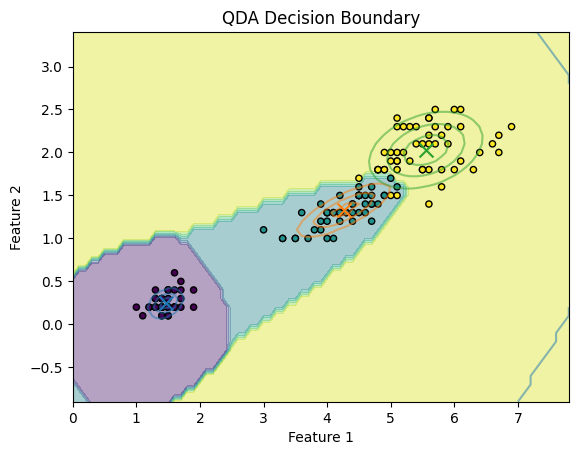

In [10]:
qda.decision_boundary(X, y)

## Linear Discriminant Analysis

## Линейный дискриминантный анализ

Допуская одинаковую для всех классов ковариацию и дисперсию признаков, задача
сводится к нахождению следующей апостериорной вероятности $ \log P (\mathbf y
\mid \pi_c, \boldsymbol \mu_c, \mathbf \Sigma)$

$$ \sum^N_{i=1} \sum^C_{c=1} \delta_{ic} \left( \log \pi_c-\frac{d}{2} \log 2\pi +
\frac{1}{2} \log | \mathbf \Sigma^{-1} | -\frac{1}{2} (\mathbf x_i-\boldsymbol
\mu_с)^\top \mathbf \Sigma^{-1} (\mathbf x_i-\boldsymbol \mu_с) \right) $$

Дифференцируя по $\pi_c$ и $ \boldsymbol \mu_с$ и приравнивая производные к
нулю, мы получим те же оценки максимального правдоподобия, что и в случае
квадратичного анализа

$$ \pi_c = \frac{N_c}{N}; \qquad \boldsymbol \mu_c = \frac{1}{N_c} \sum^N_{i=1}
\delta_{ic} \mathbf x_i. $$

MLE-оценка для $\mathbf \Sigma$ будет иной.

$$ \mathbf \Sigma = \frac{1}{N} \sum^N_{i=1} \sum^C_{c=1} \delta_{ic} (\mathbf
x_i-\boldsymbol \mu_с)(\mathbf x_i-\boldsymbol \mu_с)^\top $$

В силу того, что ковариационная матрица одинакова для всех классов, уравнение
решающей границы будет **линейным**. Воспользуемся полученными выше
результатами

$$ \begin{split} \begin{array}{ll} \pi_{c_1} |\mathbf \Sigma|^{-\frac{1}{2}} \exp \left[
\boldsymbol \mu_{c_1}^\top \mathbf \Sigma^{-1} \mathbf x-\frac{1}{2} \boldsymbol
\mu_{c_1}^\top \mathbf \Sigma^{-1} \boldsymbol \mu_{c_1}-\frac{1}{2}\mathbf
{x}^\top \mathbf \Sigma \mathbf x \right] &= \\ \pi_{c_2} |\mathbf \Sigma|^{-\frac{1}
{2}} \exp \left[ \boldsymbol \mu_{c_2}^\top \mathbf \Sigma^{-1} \mathbf x-\frac{1}{2}
\boldsymbol \mu_{c_2}^\top \mathbf \Sigma^{-1} \boldsymbol \mu_{c_2}-\frac{1}
{2}\mathbf {x}^\top \mathbf \Sigma \mathbf x \right] \end{array} \end{split}$$

и дополнительно упростим выражения

$$ \begin{split} \begin{array}{ll} \pi_{c_1} \exp \left[ \boldsymbol \mu_{c_1}^\top
\mathbf \Sigma^{-1} \mathbf x-\frac{1}{2} \boldsymbol \mu_{c_1}^\top \mathbf
\Sigma^{-1} \boldsymbol \mu_{c_1} \right] =& \\ \pi_{c_2} \exp \left[ \boldsymbol
\mu_{c_2}^\top \mathbf \Sigma^{-1} \mathbf x-\frac{1}{2} \boldsymbol
\mu_{c_2}^\top \mathbf \Sigma^{-1} \boldsymbol \mu_{c_2} \right] \end{array}
\end{split}$$

Взяв логарифм, получим

$$ \begin{split} \begin{array}{ll} \log \pi_{c_1} + \boldsymbol \mu_{c_1}^\top \mathbf
\Sigma^{-1} \mathbf x-\frac{1}{2} \boldsymbol \mu_{c_1}^\top \mathbf \Sigma^{-1}
\boldsymbol \mu_{c_1} =& \\ \log \pi_{c_2} + \boldsymbol \mu_{c_2}^\top \mathbf
\Sigma^{-1} \mathbf x-\frac{1}{2} \boldsymbol \mu_{c_2}^\top \mathbf \Sigma^{-1}
\boldsymbol \mu_{c_2} \end{array} \end{split} $$

Положив,

$$ \gamma_c = \frac{1}{2} \mathbf {\mu}^\top_c \mathbf \Sigma^{-1} \boldsymbol
\mu_c + \log \pi_c $$

$$ \mathbf \beta_c = \mathbf \Sigma^{-1} \boldsymbol \mu_c $$

получим

$$ \mathbf \beta_{c_1} \mathbf x + \gamma_{c_1} = \mathbf \beta_{c_2} \mathbf x +
\gamma_{c_2} $$

$$ (\mathbf \beta_{c_1}-\mathbf \beta_{c_2}) \mathbf x = \gamma_{c_2}-
\gamma_{c_1} $$

Реализуем алгоритм в коде.

In [11]:
class LDA:
  def __init__(self):
    self.priors = dict()
    self.means = dict()
    self.covariances = None
    self.classes = None

  def fit(self, X, y):
    self.covariances = np.cov(X, rowvar=False)
    self.classes = np.unique(y)

    for c in self.classes:
      X_c = X[y == c]
      self.priors[c] = X_c.shape[0] / X.shape[0]
      self.means[c] = np.mean(X_c, axis=0)

  def predict(self, X):
    predictions = list()
    for x in X:
      log_posteriors = list()
      for c in self.classes:
        log_priors = np.log(self.priors[c])
        inv_cov = np.linalg.inv(self.covariances)
        inv_cov_det = np.linalg.det(inv_cov)
        diff = x-self.means[c]
        log_likelihood = 0.5 * np.log(inv_cov_det) - 0.5 * diff.T @ inv_cov @ diff
        log_posterior = log_priors + log_likelihood
        log_posteriors.append(log_posterior)
      prediction = self.classes[np.argmax(log_posteriors)]
      predictions.append(prediction)
    return np.array(predictions)

  def decision_boundary(self, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    for i, _ in enumerate(self.classes):
      mean = self.means[i]
      rv = multivariate_normal(mean, self.covariances)
      x_grid, y_grid = np.mgrid[x_min:x_max:0.1, y_min:y_max:0.1]
      points = np.dstack((x_grid, y_grid))
      pdf_values = rv.pdf(points)

      plt.contour(x_grid, y_grid, pdf_values, levels=3, colors=f'C{i}', alpha=0.5)
      plt.scatter(mean[0], mean[1], marker='x', color=f'C{i}', s=100)

    plt.title('LDA Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

In [12]:
lda = LDA()
lda.fit(X, y)
accuracy_score(y, lda.predict(X))

0.86

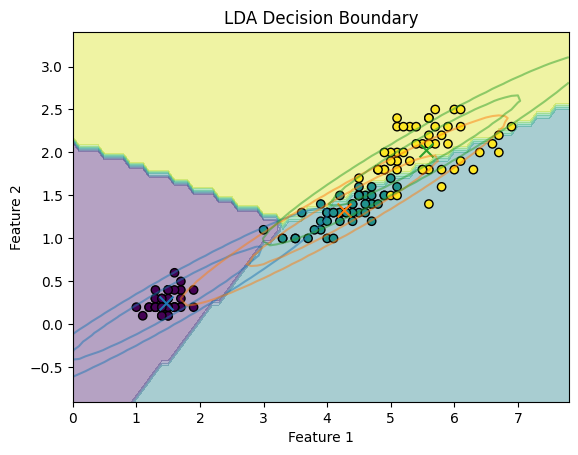

In [13]:
lda.decision_boundary(X, y)

## Gaussian Naïve Bayes

Поскольку признаки считаются независимыми, то (отдельная для каждого класса)
ковариационная матрица $\mathbf \Sigma_c$ примет вид диагональной матрицы

$$ \pi_c = \frac{N_c}{N}; \qquad \boldsymbol \mu_c = \frac{1}{N_c} \sum^N_{i=1}
\delta_{ic} \mathbf x_i; $$

$$ \mathbf \Sigma_c = diag \left( \frac{1}{N_c} \sum^N_{i=1} \delta_{ic} (\mathbf x_i-
\boldsymbol \mu_с)(\mathbf x_i-\boldsymbol \mu_с)^\top \right) $$

Покажем, что при условии независимости признаков моделирование данных с
помощью $d$-мерного нормального распределения с $\boldsymbol \mu \in
\mathbb{R}^d$ и ковариационной матрицы $\mathbf \Sigma = diag(\sigma_1^2,
\sigma_1^2, \ldots, \sigma_d^2)$ аналогично произведению $d$ независимых
одномерных нормальных распределений со средним $\mu_j$ и дисперсией
$\sigma^2_j.$

Для наглядности пусть $d=2.$ Тогда,

$$ \mathbf x = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}, \quad \boldsymbol \mu =
\begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}, \quad \mathbf \Sigma = \begin{bmatrix}
\sigma_1^2 & 0 \\ 0 & \sigma^2_2 \end{bmatrix} $$

В этом случае, многомерное нормальное распределение примет вид

$$ \begin{split} \begin{array}{ll} P(\mathbf x; \boldsymbol \mu, \mathbf \Sigma) &=
\frac{1}{2 \pi \begin{vmatrix} \sigma_1^2 & 0 \\ 0 & \sigma^2_2 \end{vmatrix}^{1/2} }
\exp \left( -\frac{1}{2} \begin{bmatrix} x_1-\mu_1 \\ x_2-\mu_2 \end{bmatrix}^\top
\begin{bmatrix} \sigma_1^2 & 0 \\ 0 & \sigma^2_2 \end{bmatrix}^{-1} \begin{bmatrix}
x_1-\mu_1 \\ x_2-\mu_2 \end{bmatrix} \right) \\ &= \frac{1}{2 \pi (\sigma^2_1 \cdot
\sigma^2_2-0 \cdot 0)^{1/2}} \exp \left( -\frac{1}{2} \begin{bmatrix} x_1-\mu_1 \\ x_2-
\mu_2 \end{bmatrix}^\top \begin{bmatrix} \frac{1}{\sigma_1^2} & 0 \\ 0 & \frac{1}
{\sigma_2^2} \end{bmatrix}^{-1} \begin{bmatrix} x_1-\mu_1 \\ x_2-\mu_2
\end{bmatrix} \right), \end{array} \end{split} $$

где мы явным образом прописываем определитель матрицы второго порядка и
находим матрицу, обратную к диагональной.

$$ \begin{split} \begin{array}{ll} P(\mathbf x; \boldsymbol \mu, \mathbf \Sigma) &=
\frac{1}{2 \pi \sigma_1 \sigma_2} \exp \left( -\frac{1}{2} \begin{bmatrix} x_1-\mu_1 \\
x_2-\mu_2 \end{bmatrix}^\top \begin{bmatrix} \frac{1}{\sigma_1^2} (x_1-\mu_1) \\
\frac{1}{\sigma_2^2} (x_2-\mu_2) \end{bmatrix} \right) \\ &= \frac{1}{2 \pi \sigma_1
\sigma_2} \exp \left( \frac{1}{2\sigma^2_1}(x_1-\mu_1)^2-\frac{1}{2\sigma^2_2}(x_2-
\mu_2)^2 \right) \\ &= \frac{1}{\sqrt{2 \pi} \sigma_1} \exp \left( -\frac{1}{2
\sigma^2_1} (x_1-\mu_1)^2 \right) \cdot \frac{1}{\sqrt{2 \pi} \sigma_2} \exp \left( -
\frac{1}{2 \sigma^2_2} (x_2-\mu_2)^2 \right) \end{array} \end{split} $$

Напишем код.

In [14]:
class GaussianNaiveBayes:
  def __init__(self):
    self.priors = dict()
    self.means = dict()
    self.covariances = dict()
    self.classes = None

  def fit(self, X, y):
    self.classes = np.unique(y)

    for c in self.classes:
      X_c = X[y == c]
      self.priors[c] = X_c.shape[0] / X.shape[0]
      self.means[c] = np.mean(X_c, axis=0)
      self.covariances[c] = np.diag(np.diag(np.cov(X_c, rowvar=False)))

  def predict(self, X):
    predictions = list()
    for x in X:
      log_posteriors = list()
      for c in self.classes:
        log_priors = np.log(self.priors[c])
        inv_cov = np.linalg.inv(self.covariances[c])
        inv_cov_det = np.linalg.det(inv_cov)
        diff = x-self.means[c]
        likelihood = 0.5 * np.log(inv_cov_det) - 0.5 * diff.T @ inv_cov @ diff
        log_posterior = log_priors + likelihood
        log_posteriors.append(log_posterior)
      prediction = self.classes[np.argmax(log_posteriors)]
      predictions.append(prediction)
    return np.array(predictions)

  def decision_boundary(self, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                          np.arange(y_min, y_max, 0.1))

    Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    for i, _ in enumerate(self.classes):
      mean = self.means[i]
      cov = np.diag(self.covariances[i])

      rv = multivariate_normal(mean, cov)
      x_grid, y_grid = np.mgrid[x_min:x_max:0.1, y_min:y_max:0.1]
      points = np.dstack((x_grid, y_grid))
      pdf_values = rv.pdf(points)

      plt.contour(x_grid, y_grid, pdf_values, levels=3, colors=f'C{i}', alpha=0.5)
      plt.scatter(mean[0], mean[1], marker='x', color=f'C{i}', s=100)

    plt.title('Gaussian Naive Bayes Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

In [15]:
gnb = GaussianNaiveBayes()
gnb.fit(X, y)
accuracy_score(y, gnb.predict(X))

0.96

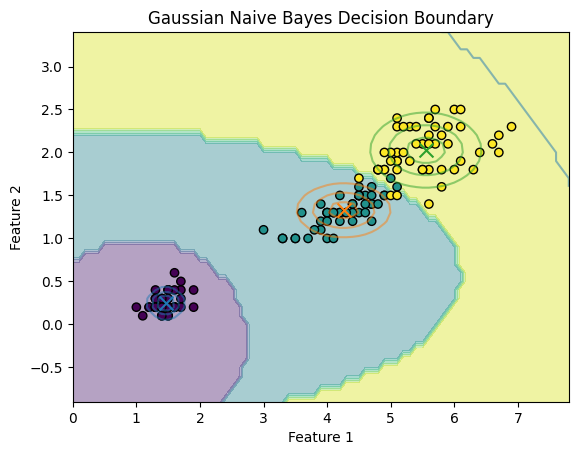

In [16]:
gnb.decision_boundary(X, y)

## LDA для понижения размерности

Можно сказать, что линейный дискриминантный анализ стремится минимизировать
**внутриклассовый разброс** (within-class scatter) $\mathbf S_W.$

$$ \mathbf S_W = \sum^N_{i=1} \sum^C_{c=1} \delta_{ic} (\mathbf x_i-\boldsymbol
\mu_с)(\mathbf x_i-\boldsymbol \mu_с)^\top $$

***Примечание.*** Поясним, что разброс $\mathbf S$ — это *общее* квадратичное
отклонение от среднего арифметического, в то время как дисперсия является
*средним* квадратичным отклонением,
$$ \mathbf S = N \mathbf \Sigma $$

При этом мы можем пойти дальше и не только минимизировать внутриклассовый
разброс, но и максимизировать **межклассовый разброс** (between-class scatter)
$\mathbf S_B.$

$$ \mathbf S_B = \sum^{C}_{c=1} N_c \cdot (\boldsymbol \mu_с-\boldsymbol \mu)
\cdot (\boldsymbol \mu_с-\boldsymbol \mu)^\top, $$

где $\boldsymbol \mu$ — вектор средних значений, рассчитанных для всех $n$
наблюдений по каждому из $d$ признаков.

Одновременное решение обеих задач можно сформулировать через максимизацию
отношения $\mathbf S_B/ \mathbf S_W $ (критерий или дискриминант Фишера,
Fisher’s criterion). Поставим задачу найти такой вектор $\mathbf w,$ что

$$ \max_w J(\mathbf w) = \frac{\mathbf w^\top \mathbf S_B \mathbf w}{\mathbf w^\top
\mathbf S_W \mathbf w} $$

Данная задача аналогична

$$ \max_w J(\mathbf w) = \mathbf w^\top \mathbf S_B \mathbf w$$

с ограничением $\mathbf w^\top \mathbf S_W \mathbf w = 1.$ Преобразуем задачу в
задачу без ограничений с помощью множителей Лагранжа

$$ \mathcal{L}(\mathbf w, \lambda) = \mathbf w^\top \mathbf S_B \mathbf w-\lambda
(\mathbf w^\top \mathbf S_W \mathbf w-1) $$

Дифференцируя по $\mathbf w,$ получим

$$ \begin{split} \begin{array}{rr} \frac{\partial \mathcal{L}}{\partial \mathbf w} &=&
2 \mathbf S_B \mathbf w-\lambda 2 \mathbf S_W \mathbf w &=& 0 \\ & & \mathbf S_B
\mathbf w &=& \lambda \mathbf S_W \mathbf w \end{array} \end{split} $$

Если $\mathbf S_W$ невырожденна, то

$$ \mathbf S_W^{-1} \mathbf S_B \mathbf w = \lambda \mathbf w $$

Таким образом, задача сводится к нахождению собственных значений и
соответствующих им собственных векторов матрицы $\mathbf S_W^{-1} \mathbf
S_B$ (generalized eigenvalue problem).

Используя первые $m$ собственных векторов $\mathbf w,$ соответствующих
наибольшим $m$ собственным значениям, мы получим матрицу $\mathbf W_{d
\times m},$ которая при умножении на матрицу данных $\mathbf X_{n \times d}$
преобразует последнюю в пространство меньшей размерности $\mathbf Z_{n \times
m}.$

$$ \mathbf Z = \mathbf X \cdot \mathbf W $$

В частности, для $m=2$ получим,

$$ \mathbf Z = \mathbf X \cdot \mathbf W = \begin{pmatrix} x_{11} & x_{12} & \dots
& x_{1d} \\ x_{21} & x_{22} & \dots & x_{2d} \\ \vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \dots & x_{nd} \end{pmatrix} \cdot \underbrace{ \begin{pmatrix}
w_1^{(1)} & w_1^{(2)} \\ w_2^{(1)} & w_2^{(2)} \\ \vdots & \vdots \\ w_d^{(1)} &
w_d^{(2)} \end{pmatrix} }_{m=2} = \begin{pmatrix} \vert & \vert \\ \mathbf {LD1} &
\mathbf {LD2} \\ \vert & \vert \end{pmatrix} $$

Новые признаки, максимизирующие $ \mathbf S_B $ и минимизирующие $ \mathbf
S_W,$ называются **линейными дискриминантами** (linear discriminants, LD).

In [17]:
class LDA:
  def __init__(self):
    self.priors = dict()
    self.means = dict()
    self.covariances = None
    self.classes = None

  def fit(self, X, y):
    self.covariances = np.cov(X, rowvar=False)
    self.classes = np.unique(y)

    for c in self.classes:
      X_c = X[y == c]
      self.priors[c] = X_c.shape[0] / X.shape[0]
      self.means[c] = np.mean(X_c, axis=0)

  def predict(self, X):
    predictions = list()
    for x in X:
      log_posteriors = list()
      for c in self.classes:
        log_priors = np.log(self.priors[c])
        inv_cov = np.linalg.inv(self.covariances)
        inv_cov_det = np.linalg.det(inv_cov)
        diff = x-self.means[c]
        log_likelihood = 0.5 * np.log(inv_cov_det) - 0.5 * diff.T @ inv_cov @ diff
        log_posterior = log_priors + log_likelihood
        log_posteriors.append(log_posterior)
      prediction = self.classes[np.argmax(log_posteriors)]
      predictions.append(prediction)
    return np.array(predictions)

  def fit_transform(self, X, y, n_components=2):
    self.classes = np.unique(y)
    n_features = X.shape[1]
    overall_mean = np.mean(X, axis=0)
    SW = np.zeros((n_features, n_features))
    SB = np.zeros((n_features, n_features))

    for c in self.classes:
      X_c = X[y == c]
      mean_c = np.mean(X_c, axis=0)
      SW += (X_c - mean_c).T.dot((X_c - mean_c))
      n_c = X_c.shape[0]
      mean_diff = (mean_c - overall_mean).reshape(n_features, 1)
      SB += n_c * (mean_diff).dot(mean_diff.T)

    A = np.linalg.inv(SW).dot(SB)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors.T)

    idxs = np.argsort(np.abs(eigenvalues))[::-1]
    eigenvalues = np.abs(eigenvalues[idxs])
    eigenvectors = eigenvectors[idxs]
    W = eigenvectors[:n_components]

    return np.dot(X, W.T)

  def decision_boundary(self, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    for i, _ in enumerate(self.classes):
      mean = self.means[i]
      rv = multivariate_normal(mean, self.covariances)
      x_grid, y_grid = np.mgrid[x_min:x_max:0.1, y_min:y_max:0.1]
      points = np.dstack((x_grid, y_grid))
      pdf_values = rv.pdf(points)

      plt.contour(x_grid, y_grid, pdf_values, levels=3, colors=f'C{i}', alpha=0.5)
      plt.scatter(mean[0], mean[1], marker='x', color=f'C{i}', s=100)

    plt.title('Linear Discriminant Analysis Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

In [18]:
iris = load_iris()
X, y = iris.data, iris.target

In [19]:
lda = LDA()
# понизим размерность с четырех до двух измерений
X_lda = lda.fit_transform(X, y, n_components=2)
X.shape, X_lda.shape

((150, 4), (150, 2))

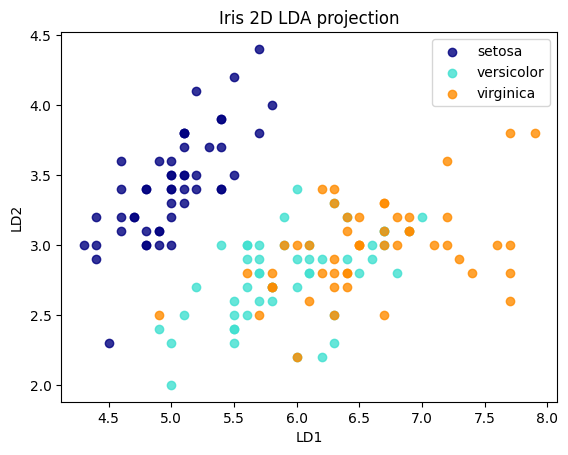

In [20]:
colors = ['navy', 'turquoise', 'darkorange']

plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
  plt.scatter(X[y == i, 0], X[y == i, 1],
              alpha=0.8, color=color, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Iris 2D LDA projection')
plt.xlabel('LD1')
plt.ylabel('LD2')

plt.show()